# Copernicus Solar Forecasting - final beta

## Rappel du challenge

Le challenge consiste à prévoir le rayonnement solaire global horizontal (GHI) sur les quatre horizons futurs `t+15`, `t+30`, `t+45` et `t+60` minutes, sous forme de cartes `51 × 51` pixels centrées sur la zone d'intérêt.

Les entrées combinent :
- les quatre dernières images `GHI` ;
- les huit images `CLS` (clear-sky) ;
- les angles solaires `SZA/SAA`.

La stratégie retenue consiste à comparer une **baseline physique forte** (`persistence_csi`) à des modèles tabulaires, puis à des variantes plus locales / plus spatiales.

### Formulation du problème
À l'instant `t`, on observe :
- les **4 dernières images** de `GHI` sur l'**Observation Region** (OR) de taille `81 x 81`,
- les variables contextuelles `CLS`, `SZA` et `SAA`, disponibles sur 8 pas de temps (passés + futurs).

On veut prédire :
- les **4 prochaines images** de `GHI`
- aux horizons `t+15`, `t+30`, `t+45`, `t+60`
- sur la **Region of Interest** (RoI) centrale de taille `51 x 51`.

### Interprétation ML
Le problème est une **régression spatio-temporelle multi-sortie** :
- entrée : une séquence d'images multicanales,
- sortie : une séquence future d'images.

Cela justifie deux familles d'approches :
- des **features tabulaires** pour des modèles classiques,
- des **tenseurs image/canaux** pour des CNN ou autres modèles deep learning.


### Variables
- **GHI** : irradiance observée, variable centrale du problème ;
- **CLS** : irradiance de ciel clair, référence physique sans nuages ;
- **SZA** : angle zénithal solaire ;
- **SAA** : angle azimutal solaire.

### Zones
- **OR (Observation Region)** : `81 x 81` pixels ;
- **RoI (Region of Interest)** : `51 x 51` pixels, zone centrale à prédire.

Le recadrage de l'OR vers la RoI permet :
- d'aligner directement les entrées avec la cible,
- de réduire le volume des données,
- tout en conservant la zone de prédiction pertinente.

## 0. Setup & chargement

Par défaut, le notebook peut être lancé sur `sample` pour itérer rapidement.  
Pour les résultats finaux, il faut passer à `full`.  
La partie **deep learning** est prévue pour être lancée de préférence sur **Google Colab**.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import FORECAST_HORIZONS_MINUTES, INPUT_VARIABLES
from src.baselines import mean_image_baseline, persistence_csi_baseline, persistence_last_ghi_baseline
from src.data_loading import open_processed_profile, prepare_processed_profile, processed_profile_exists
from src.deep_learning import (
    build_convlstm_residual_model,
    build_small_residual_cnn,
    fit_mlp_residual_mean,
    has_tensorflow,
    prepare_cnn_training_data,
    prepare_convlstm_training_data,
    target_from_channels_last,
    add_residual_mean_to_baseline,
)
from src.eda import descriptive_stats, target_horizon_stats
from src.experiment_io import list_saved_outputs, load_saved_predictions, save_prediction_bundle
from src.features import (
    build_advanced_features,
    build_exogenous_features,
    build_physical_inputs,
    build_spatial_dynamics_features,
    build_spatial_feature_tensor,
    build_tabular_features,
)
from src.interpretation import (
    compute_tree_shap_values,
    model_feature_importances,
    permutation_importance_multioutput,
)
from src.metrics import (
    build_model_diagnostics,
    cluster_balance_report,
    cluster_quality,
    evaluate_model_bundle,
    global_metrics_row,
    metrics_by_cluster,
    rmse,
    spatial_mean_residual,
)
from src.motion import advective_csi_baseline, estimate_motion_vectors, has_opencv
from src.preprocessing import temporal_train_validation_split
from src.texture import build_texture_features
from src.visualization import (
    horizon_titles,
    plot_cluster_metric,
    plot_forecast_triplet,
    plot_metric_by_horizon,
    plot_motion_summary,
    plot_sequence,
)
from models.models_tabular import (
    fit_elasticnet_multioutput,
    fit_extra_trees_multioutput,
    fit_hist_gb_multioutput,
    fit_random_forest_multioutput,
    fit_ridge_multioutput,
    patchwise_predictions_to_map,
    patchwise_target_means,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
RANDOM_STATE = 42
PROFILE = "full"  # "dev" pour smoke test, puis "sample" ou "full"
MAIN_REFERENCE_NAME = "persistence_csi"

RUN_FAST = PROFILE == "dev"
RUN_LOCAL_ML = True
RUN_DEEP_LEARNING = False  # mettre True sur Colab
RUN_XAI = True
RUN_SHAP = True

SAVE_OUTPUTS = True
LOAD_SAVED_OUTPUTS = True
OVERWRITE_OUTPUTS = True
OUTPUT_DIR = ROOT / "reports" / "model_outputs" / "final_beta" / PROFILE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)
print("ROOT:", ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

ROOT: c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting
OUTPUT_DIR: c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting\reports\model_outputs\final_beta\full


## 1. Chargement, split et EDA rapide

In [3]:
if not processed_profile_exists(PROFILE, split="train"):
    prepare_processed_profile(PROFILE, split="train", overwrite=False)

data = open_processed_profile(PROFILE, split="train", variables=INPUT_VARIABLES, mmap_mode=None)
arrays = {name: np.asarray(values, dtype=np.float32) for name, values in data["X"].items()}
y = np.asarray(data["y"], dtype=np.float32)

train_idx, val_idx = temporal_train_validation_split(len(y), validation_fraction=0.2)
train_arrays_raw = {name: values[train_idx] for name, values in arrays.items()}
val_arrays_raw = {name: values[val_idx] for name, values in arrays.items()}
train_target = y[train_idx]
val_target = y[val_idx]

print(f"Profil: {PROFILE}")
print(f"Samples: total={len(y)}, train={len(train_idx)}, validation={len(val_idx)}")
print({name: value.shape for name, value in arrays.items()})
display(descriptive_stats(arrays, y))
display(target_horizon_stats(y))

Profil: full
Samples: total=1845, train=1476, validation=369
{'GHI': (1845, 4, 51, 51), 'CLS': (1845, 8, 51, 51), 'SZA': (1845, 8, 51, 51), 'SAA': (1845, 8, 51, 51)}


,variable,shape,mean,std,min,median,max
0,GHI,"(1845, 4, 51, 51)",501.326935,273.921478,8.040000,499.649994,1099.449951
1,CLS,"(1845, 8, 51, 51)",576.162415,253.484070,34.450001,567.429993,1119.270020
2,SZA,"(1845, 8, 51, 51)",175.404953,60.614697,65.910004,173.330002,285.309998
3,SAA,"(1845, 8, 51, 51)",52.772953,17.380068,12.980000,55.619999,85.449997
4,target,"(1845, 4, 51, 51)",510.516968,261.338043,7.330000,472.369995,1093.689941


,horizon_min,mean,std,min,median,max
0,15,511.794189,258.839478,19.34,486.140015,1093.689941
1,30,512.276611,258.324799,14.93,472.820007,1084.849976
2,45,510.756714,261.177277,10.13,457.950012,1077.020020
3,60,507.240509,266.892487,7.33,469.109985,1087.630005


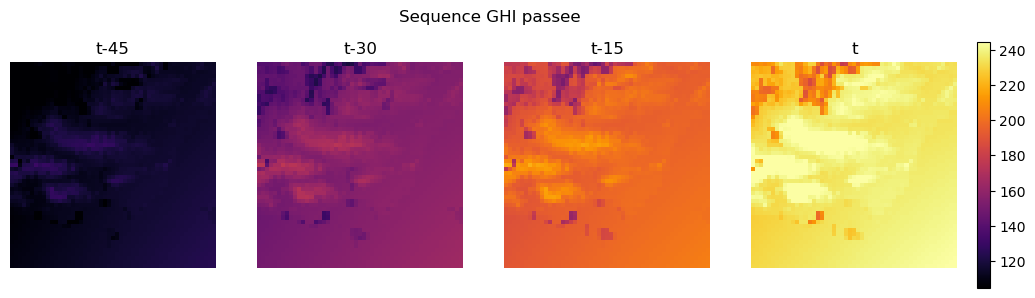

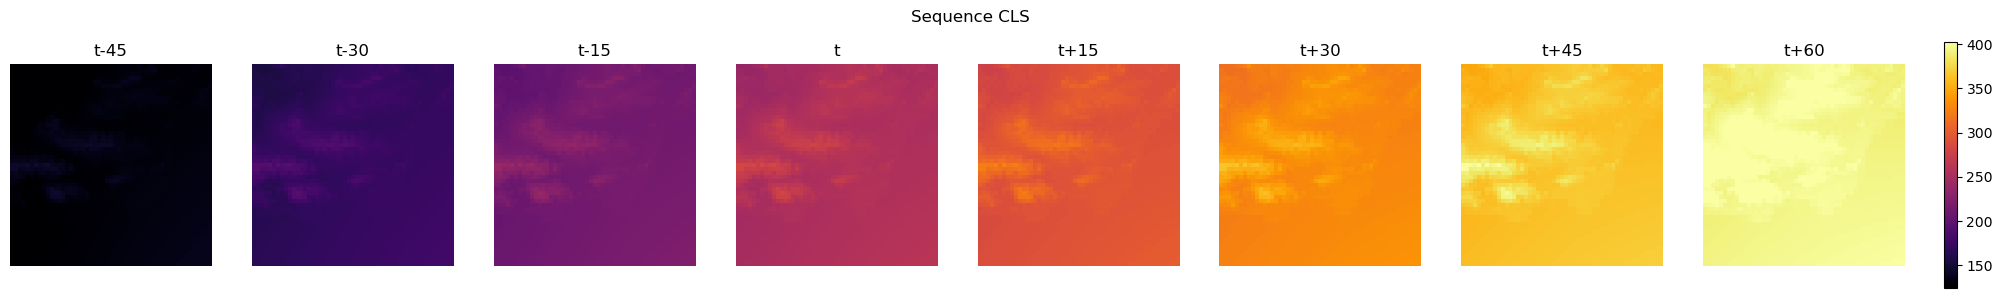

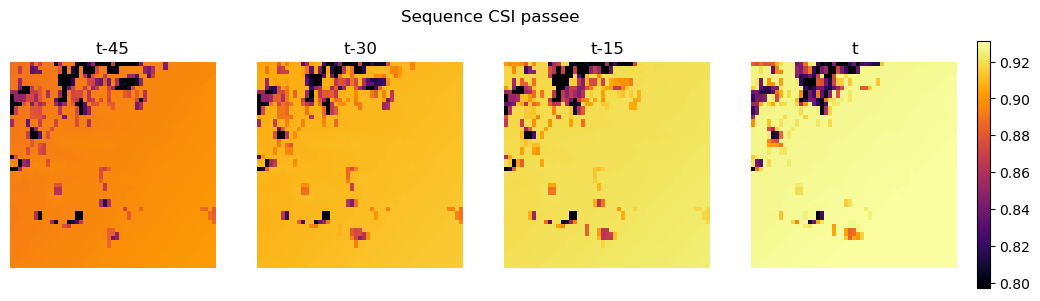

In [4]:
sample_id = 0
sample_phys = build_physical_inputs({name: values[[sample_id]] for name, values in arrays.items()}, keep_raw_ghi=True)
sample_csi = sample_phys["CSI"][0]

plot_sequence(arrays["GHI"][sample_id], titles=["t-45", "t-30", "t-15", "t"], suptitle="Sequence GHI passee")
plt.show()
plot_sequence(arrays["CLS"][sample_id], titles=["t-45", "t-30", "t-15", "t", "t+15", "t+30", "t+45", "t+60"], suptitle="Sequence CLS")
plt.show()
plot_sequence(sample_csi, titles=["t-45", "t-30", "t-15", "t"], suptitle="Sequence CSI passee")
plt.show()

## 2. Construction des features communes

Vent U/V absent des fichiers: pas de features exogenes ajoutees.
OpenCV disponible: False
Feature matrix: (1476, 628)


,count,mean,std,min,25%,50%,75%,max
phys_CSI_mean_t0,1476.0,0.880412,0.124901,0.143136,0.846034,0.921615,0.964935,1.002780
phys_CSI_std_t0,1476.0,0.082471,0.069276,0.001421,0.024556,0.063255,0.127203,0.317049
phys_CSI_min_t0,1476.0,0.527376,0.259031,0.093864,0.292224,0.536363,0.757906,0.982073
phys_CSI_max_t0,1476.0,0.964526,0.043581,0.446953,0.957681,0.976410,0.991968,1.020442
phys_CSI_mean_t1,1476.0,0.880345,0.128423,0.147248,0.844999,0.922198,0.965784,1.002667
phys_CSI_std_t1,1476.0,0.084777,0.071150,0.001376,0.024935,0.064601,0.132382,0.322224
phys_CSI_min_t1,1476.0,0.520147,0.266480,0.094576,0.268508,0.535634,0.752697,0.981175
phys_CSI_max_t1,1476.0,0.967008,0.039864,0.475089,0.956523,0.976917,0.991954,1.019928
phys_CSI_mean_t2,1476.0,0.881551,0.128337,0.153504,0.848248,0.922083,0.965704,1.002711
phys_CSI_std_t2,1476.0,0.085331,0.071600,0.001110,0.025301,0.066161,0.131844,0.316081


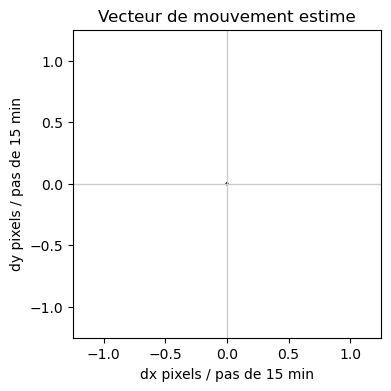

In [5]:
train_phys = build_physical_inputs(train_arrays_raw, keep_raw_ghi=True, encode_angles=True)
val_phys = build_physical_inputs(val_arrays_raw, keep_raw_ghi=True, encode_angles=True)

train_motion = estimate_motion_vectors(train_phys["CSI"], use_farneback=None).add_prefix("flow_")
val_motion = estimate_motion_vectors(val_phys["CSI"], use_farneback=None).add_prefix("flow_")
train_texture = build_texture_features(train_phys, variable="CSI", time_index=-1).add_prefix("tex_")
val_texture = build_texture_features(val_phys, variable="CSI", time_index=-1).add_prefix("tex_")
train_spatial_dyn = build_spatial_dynamics_features(train_arrays_raw).add_prefix("spdyn_")
val_spatial_dyn = build_spatial_dynamics_features(val_arrays_raw).add_prefix("spdyn_")
train_exogenous = build_exogenous_features(train_arrays_raw).add_prefix("exo_")
val_exogenous = build_exogenous_features(val_arrays_raw).add_prefix("exo_")

feature_blocks_train = [
    build_tabular_features(train_phys).add_prefix("phys_"),
    build_advanced_features(train_arrays_raw).add_prefix("adv_"),
    train_motion,
    train_texture,
    train_spatial_dyn,
]
feature_blocks_val = [
    build_tabular_features(val_phys).add_prefix("phys_"),
    build_advanced_features(val_arrays_raw).add_prefix("adv_"),
    val_motion,
    val_texture,
    val_spatial_dyn,
]
if len(train_exogenous.columns):
    feature_blocks_train.append(train_exogenous)
    feature_blocks_val.append(val_exogenous)
else:
    print("Vent U/V absent des fichiers: pas de features exogenes ajoutees.")

X_train_features = pd.concat(feature_blocks_train, axis=1)
X_val_features = pd.concat(feature_blocks_val, axis=1)
common_cols = [col for col in X_train_features.columns if col in X_val_features.columns]
X_train_features = X_train_features[common_cols].replace([np.inf, -np.inf], np.nan)
X_val_features = X_val_features[common_cols].replace([np.inf, -np.inf], np.nan)
medians = X_train_features.median(numeric_only=True).fillna(0.0)
X_train_features = X_train_features.fillna(medians)
X_val_features = X_val_features.fillna(medians)

scaler = StandardScaler()
X_train_tab = scaler.fit_transform(X_train_features).astype(np.float32)
X_val_tab = scaler.transform(X_val_features).astype(np.float32)
feature_names = list(X_train_features.columns)

print("OpenCV disponible:", has_opencv())
print("Feature matrix:", X_train_tab.shape)
display(X_train_features.describe().T.head(30))
plot_motion_summary(train_motion, sample_idx=0)
plt.show()

## Bloc A - Baselines

Baselines retenues:

- Persistance brute: repete la derniere image GHI.
- Persistance CSI: repete le dernier clear-sky index puis remultiplie par le CLS futur.
- Advective CSI: deplace le dernier CSI selon le mouvement nuageux estime.

In [6]:
y_pred_persistence_raw = persistence_last_ghi_baseline(val_arrays_raw)
y_pred_persistence_csi = persistence_csi_baseline(val_arrays_raw)
y_pred_train_csi = persistence_csi_baseline(train_arrays_raw)
y_pred_advective_csi = advective_csi_baseline(
    val_arrays_raw,
    motion_features=val_motion.rename(columns=lambda col: col.replace("flow_", "")),
)
y_pred_mean = mean_image_baseline(train_target, n_samples=len(val_target))

predictions = {
    "persistence_raw": y_pred_persistence_raw,
    "persistence_csi": y_pred_persistence_csi,
    "advective_csi": y_pred_advective_csi,
    "mean_image": y_pred_mean,
}
baseline_diagnostics = build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)
display(baseline_diagnostics["global"])
display(baseline_diagnostics["by_horizon"].sort_values(["horizon_min", "RMSE"]))

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
1,advective_csi,49.572551,27.820193,-3.432155,10.741379,76.496201,0.149388,0.917105,12.262212,0.994425,-2.653997e-01
2,persistence_raw,83.515920,65.760217,0.345245,50.570007,144.649994,0.251677,0.764721,29.931432,0.893965,-2.591565e+00
3,mean_image,282.065124,241.754936,223.349541,232.432251,445.568024,0.850010,-1.683758,161.744619,0.019122,-3.996793e+01


,horizon_min,RMSE,MAE,bias,P90AE,corr_spatial_mean,skill_RMSE_vs_ref,skill_MAE_vs_ref,model
4,15,21.562305,12.647155,-1.998343,35.052832,0.998831,4.637724e-10,7.906917e-10,persistence_csi
8,15,26.843404,15.103280,-1.811409,41.202304,0.998899,-2.449228e-01,-1.942037e-01,advective_csi
0,15,34.233336,28.551074,-2.447420,50.460022,0.984782,-5.876473e-01,-1.257509e+00,persistence_raw
12,15,278.422182,239.324298,221.455159,425.634229,NaN,-1.191245e+01,-1.792317e+01,mean_image
5,30,36.658937,21.649818,-3.337098,59.924213,0.996089,2.727848e-10,4.618977e-10,persistence_csi
9,30,43.434070,25.200741,-3.169489,69.066347,0.996262,-1.848153e-01,-1.640163e-01,advective_csi
1,30,63.912946,54.024610,-2.122095,98.000000,0.940796,-7.434479e-01,-1.495384e+00,persistence_raw
13,30,279.487223,240.197164,222.464879,428.208868,NaN,-6.623986e+00,-1.009465e+01,mean_image
6,45,49.864106,29.614452,-4.368226,81.901978,0.992697,2.005450e-10,3.376730e-10,persistence_csi
10,45,55.652119,32.865735,-4.039340,90.429010,0.993004,-1.160757e-01,-1.097870e-01,advective_csi


## Bloc B - ML tabulaire

Les modeles apprennent une correction residuelle moyenne par horizon par rapport a la persistance CSI. Cela force les modeles tabulaires a corriger une baseline physique forte plutot qu'a reconstruire toute l'image.

In [7]:
residual_train = spatial_mean_residual(train_target, y_pred_train_csi)
residual_val = spatial_mean_residual(val_target, y_pred_persistence_csi)
model_registry = {}
supervised_predictions = {}

if RUN_LOCAL_ML:
    ridge_model = fit_ridge_multioutput(X_train_tab, residual_train, alpha=10.0, random_state=RANDOM_STATE)
    supervised_predictions["ridge_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, ridge_model.predict(X_val_tab))
    model_registry["ridge_residual_csi"] = ridge_model

    elastic_model = fit_elasticnet_multioutput(
        X_train_tab,
        residual_train,
        alpha=0.001,
        l1_ratio=0.2,
        random_state=RANDOM_STATE,
        max_iter=2000,
    )
    supervised_predictions["elasticnet_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, elastic_model.predict(X_val_tab))
    model_registry["elasticnet_residual_csi"] = elastic_model

    extra_model = fit_extra_trees_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=40 if RUN_FAST else 250,
        max_depth=8 if RUN_FAST else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    supervised_predictions["extra_trees_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, extra_model.predict(X_val_tab))
    model_registry["extra_trees_residual_csi"] = extra_model

    rf_model = fit_random_forest_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=30 if RUN_FAST else 200,
        max_depth=6 if RUN_FAST else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    supervised_predictions["random_forest_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, rf_model.predict(X_val_tab))
    model_registry["random_forest_residual_csi"] = rf_model

In [ ]:
hgb_grid = {
    "learning_rate": [0.05, 0.10] if RUN_FAST else [0.03, 0.05, 0.08],
    "max_iter": [40] if RUN_FAST else [150, 250],
    "max_leaf_nodes": [15, 31],
    "min_samples_leaf": [5] if RUN_FAST else [10, 20],
    "l2_regularization": [0.0] if RUN_FAST else [0.0, 0.1],
}
inner_train_idx, inner_val_idx = temporal_train_validation_split(len(residual_train), validation_fraction=0.25)
hgb_rows = []
best_hgb_score = np.inf
best_hgb_params = None

for params in ParameterGrid(hgb_grid):
    candidate = fit_hist_gb_multioutput(
        X_train_tab[inner_train_idx],
        residual_train[inner_train_idx],
        random_state=RANDOM_STATE,
        **params,
    )
    pred = candidate.predict(X_train_tab[inner_val_idx])
    score = float(np.sqrt(np.mean((pred - residual_train[inner_val_idx]) ** 2)))
    row = dict(params)
    row["inner_RMSE_residual_mean"] = score
    hgb_rows.append(row)
    if score < best_hgb_score:
        best_hgb_score = score
        best_hgb_params = params

hgb_tuning = pd.DataFrame(hgb_rows).sort_values("inner_RMSE_residual_mean")
display(hgb_tuning)
print("Best HistGB params:", best_hgb_params)

if RUN_LOCAL_ML:
    hgb_model = fit_hist_gb_multioutput(X_train_tab, residual_train, random_state=RANDOM_STATE, **best_hgb_params)
    supervised_predictions["hist_gb_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, hgb_model.predict(X_val_tab))
    model_registry["hist_gb_residual_csi"] = hgb_model

predictions.update(supervised_predictions)
ml_diagnostics = build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)
display(ml_diagnostics["global"])
plot_metric_by_horizon(ml_diagnostics["by_horizon"], models=list(ml_diagnostics["global"]["model"].head(6)), metric="RMSE")
plt.show()

Exception in thread Thread-64 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x82 in position 101: invalid start byte


### Variante spatiale patch-wise

In [ ]:
spatial_predictions = {}
residual_train_maps = train_target - y_pred_train_csi
residual_patch_train, patch_names = patchwise_target_means(residual_train_maps, n_rows=2, n_cols=2)
residual_patch_val, _ = patchwise_target_means(val_target - y_pred_persistence_csi, n_rows=2, n_cols=2)

if RUN_LOCAL_ML:
    patch_hgb_model = fit_hist_gb_multioutput(
        X_train_tab,
        residual_patch_train,
        learning_rate=0.05,
        max_iter=60 if RUN_FAST else 180,
        max_leaf_nodes=15,
        min_samples_leaf=5 if RUN_FAST else 10,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )
    patch_pred = patch_hgb_model.predict(X_val_tab)
    spatial_predictions["hist_gb_patch2x2_residual_csi"] = patchwise_predictions_to_map(
        y_pred_persistence_csi,
        patch_pred,
        n_rows=2,
        n_cols=2,
    )
    model_registry["hist_gb_patch2x2_residual_csi"] = patch_hgb_model

predictions.update(spatial_predictions)
patch_diagnostics = build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)
display(patch_diagnostics["global"])

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,random_forest_residual_csi,13.278936,6.398546,0.322359,1.834564,19.164864,0.036163,0.990820,2.123090,0.999986,5.954273e-02
1,extra_trees_residual_csi,13.282668,6.381932,0.163779,1.905746,19.072876,0.036173,0.990815,2.106022,0.999971,5.901394e-02
2,hist_gb_residual_csi,13.350894,6.699421,0.337312,2.685139,19.355685,0.036359,0.990721,2.186785,0.999948,4.932240e-02
3,ridge_residual_csi,13.383484,6.542297,0.060480,1.765686,19.293857,0.036447,0.990675,2.152280,0.999915,4.467547e-02
4,hist_gb_patch2x2_residual_csi,13.445898,6.875939,0.744477,2.260624,19.385791,0.036617,0.990588,2.328370,0.999959,3.574438e-02
5,elasticnet_residual_csi,13.494951,6.855626,0.204269,2.168564,19.274329,0.036751,0.990519,2.222436,0.999852,2.869603e-02
6,persistence_csi,13.692846,7.372206,-0.417489,3.536774,19.419833,0.037290,0.990239,2.556798,0.999774,5.333511e-11
7,advective_csi,18.462959,9.137542,-0.139323,3.626373,24.591437,0.050280,0.982254,3.224402,0.999755,-8.180892e-01
8,persistence_raw,77.652985,63.439056,18.745708,44.149979,131.770004,0.211473,0.686080,27.925336,0.839601,-3.116095e+01
9,mean_image,138.899038,125.968348,-14.861553,128.661423,199.910825,0.378265,-0.004387,50.034306,0.081565,-1.018990e+02


## Bloc C - Non supervise

Le clustering est realise sur les features meteo, texture et motion. Il sert a interpreter les regimes de ciel, puis a evaluer la robustesse des modeles par regime.

In [ ]:
cluster_feature_names = [
    col for col in feature_names
    if any(token in col for token in ["CSI_mean", "CSI_std", "CSI_trend", "GHI_mean", "GHI_std", "flow_", "tex_", "spdyn_"])
]
if len(cluster_feature_names) < 3:
    cluster_feature_names = feature_names

X_cluster_train = X_train_features[cluster_feature_names].to_numpy(dtype=np.float32)
X_cluster_val = X_val_features[cluster_feature_names].to_numpy(dtype=np.float32)
cluster_scaler = StandardScaler()
X_cluster_train_scaled = cluster_scaler.fit_transform(X_cluster_train)
X_cluster_val_scaled = cluster_scaler.transform(X_cluster_val)

cluster_pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_cluster_train_emb = cluster_pca.fit_transform(X_cluster_train_scaled)
X_cluster_val_emb = cluster_pca.transform(X_cluster_val_scaled)

k_values = [2, 3] if RUN_FAST else [2, 3, 4, 5]
cluster_rows = []
best_kmeans = None
best_score = -np.inf
min_cluster_size_required = max(3, int(0.05 * len(X_cluster_train_emb)))
for k in k_values:
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster_train_emb)
    quality = cluster_quality(X_cluster_train_emb, labels)
    qmap = dict(zip(quality["metric"], quality["value"])) if not quality.empty else {}
    counts = pd.Series(labels).value_counts()
    row = {
        "method": "kmeans",
        "k": k,
        "silhouette": qmap.get("silhouette", np.nan),
        "calinski_harabasz": qmap.get("calinski_harabasz", np.nan),
        "davies_bouldin": qmap.get("davies_bouldin", np.nan),
        "min_cluster_size": int(counts.min()),
    }
    cluster_rows.append(row)
    if row["min_cluster_size"] >= min_cluster_size_required and row["silhouette"] > best_score:
        best_score = row["silhouette"]
        best_kmeans = km

cluster_search = pd.DataFrame(cluster_rows).sort_values("silhouette", ascending=False)
display(cluster_search)
if best_kmeans is None:
    best_k = int(cluster_search.iloc[0]["k"])
    best_kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE).fit(X_cluster_train_emb)

train_clusters = best_kmeans.predict(X_cluster_train_emb)
val_clusters = best_kmeans.predict(X_cluster_val_emb)
display(cluster_balance_report(train_clusters))
display(cluster_balance_report(val_clusters))

,method,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size
1,kmeans,3,0.243526,7.236538,1.512550,6
0,kmeans,2,0.223377,8.029893,1.665517,11


,cluster,n,share
0,0,6,0.24
1,1,13,0.52
2,2,6,0.24


,cluster,n,share
0,1,3,0.428571
1,2,4,0.571429


,cluster,n,csi_mean,texture_entropy,motion_speed,regime
0,2,4,0.896502,2.956642,0.536821,couvert
1,1,3,0.940685,2.239365,0.226864,partiellement_nuageux


,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
3,random_forest_residual_csi,2,couvert,4,16.131613,8.553125,0.524445,23.746567,0.045820,3.577001e-02
1,persistence_csi,2,couvert,4,16.428105,9.641323,-0.662926,24.035141,0.046663,3.705314e-11
2,random_forest_residual_csi,1,partiellement_nuageux,3,8.029013,3.525773,0.052912,4.558670,0.020726,1.697202e-01
0,persistence_csi,1,partiellement_nuageux,3,8.811502,4.346719,-0.090239,6.155542,0.022746,1.287953e-10


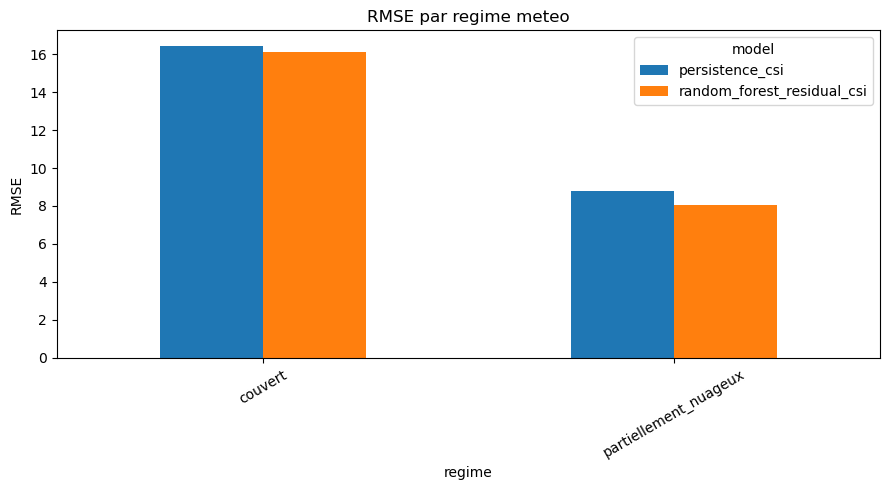

In [ ]:
cluster_frame = X_val_features.copy()
cluster_frame["cluster"] = val_clusters
csi_col = "phys_CSI_mean_t3" if "phys_CSI_mean_t3" in cluster_frame.columns else cluster_feature_names[0]
texture_col = "tex_csi_t-1_glcm_entropy" if "tex_csi_t-1_glcm_entropy" in cluster_frame.columns else csi_col
motion_col = "flow_motion_speed_last" if "flow_motion_speed_last" in cluster_frame.columns else csi_col

cluster_summary = (
    cluster_frame
    .groupby("cluster")
    .agg(
        n=(csi_col, "size"),
        csi_mean=(csi_col, "mean"),
        texture_entropy=(texture_col, "mean"),
        motion_speed=(motion_col, "mean"),
    )
    .sort_values(["csi_mean", "texture_entropy"])
)

regime_names = ["couvert", "partiellement_nuageux", "ciel_clair", "tres_variable", "mixte"]
cluster_name_map = {cluster: regime_names[i] for i, cluster in enumerate(cluster_summary.index)}
cluster_summary["regime"] = [cluster_name_map[idx] for idx in cluster_summary.index]
display(cluster_summary.reset_index())

cluster_perf_tables = []
for model_name in [MAIN_REFERENCE_NAME, patch_diagnostics["global"].iloc[0]["model"]]:
    cluster_perf_tables.append(
        metrics_by_cluster(
            val_target,
            predictions[model_name],
            val_clusters,
            model_name,
            cluster_name_map=cluster_name_map,
            reference_pred=predictions[MAIN_REFERENCE_NAME],
        )
    )
cluster_perf = pd.concat(cluster_perf_tables, ignore_index=True)
display(cluster_perf.sort_values(["regime", "RMSE"]))
plot_cluster_metric(cluster_perf, metric="RMSE")
plt.show()

## Bloc D - Deep Learning

A executer sur Colab pour TensorFlow/GPU:

- CNN residuel: entree cartes en canaux, sortie residual maps.
- ConvLSTM residuel: entree sequentielle `(CSI, GHI, CLS, SZA/SAA sin/cos)`, sortie residual maps.

Les predictions DL peuvent etre sauvegardees dans `OUTPUT_DIR`, puis rechargees localement dans la comparaison finale.

In [ ]:
dl_predictions = {}
if RUN_DEEP_LEARNING:
    spatial_train_tensor, spatial_feature_names = build_spatial_feature_tensor(
        build_physical_inputs(train_arrays_raw, keep_raw_ghi=False, encode_angles=True)
    )
    spatial_val_tensor, _ = build_spatial_feature_tensor(
        build_physical_inputs(val_arrays_raw, keep_raw_ghi=False, encode_angles=True)
    )
    X_train_cnn, y_train_cnn = prepare_cnn_training_data(spatial_train_tensor, train_target, baseline=y_pred_train_csi)
    X_val_cnn, y_val_cnn = prepare_cnn_training_data(spatial_val_tensor, val_target, baseline=y_pred_persistence_csi)

    X_train_convlstm, y_train_convlstm, convlstm_channels = prepare_convlstm_training_data(
        train_arrays_raw,
        train_target,
        baseline=y_pred_train_csi,
    )
    X_val_convlstm, y_val_convlstm, _ = prepare_convlstm_training_data(
        val_arrays_raw,
        val_target,
        baseline=y_pred_persistence_csi,
    )

    if has_tensorflow():
        cnn_model = build_small_residual_cnn(
            input_shape=X_train_cnn.shape[1:],
            n_horizons=len(FORECAST_HORIZONS_MINUTES),
            learning_rate=1e-3,
        )
        cnn_model.fit(
            X_train_cnn,
            y_train_cnn,
            validation_data=(X_val_cnn, y_val_cnn),
            epochs=3 if RUN_FAST else 20,
            batch_size=8 if RUN_FAST else 32,
            verbose=1,
        )
        cnn_residual = target_from_channels_last(cnn_model.predict(X_val_cnn, verbose=0))
        dl_predictions["cnn_residual_csi_fullmap"] = np.maximum(y_pred_persistence_csi + cnn_residual, 0.0)

        convlstm_model = build_convlstm_residual_model(
            input_shape=X_train_convlstm.shape[1:],
            n_horizons=len(FORECAST_HORIZONS_MINUTES),
            learning_rate=1e-3,
        )
        convlstm_model.fit(
            X_train_convlstm,
            y_train_convlstm,
            validation_data=(X_val_convlstm, y_val_convlstm),
            epochs=3 if RUN_FAST else 25,
            batch_size=4 if RUN_FAST else 16,
            verbose=1,
        )
        convlstm_residual = target_from_channels_last(convlstm_model.predict(X_val_convlstm, verbose=0))
        dl_predictions["convlstm_residual_csi_fullmap"] = np.maximum(y_pred_persistence_csi + convlstm_residual, 0.0)
    else:
        print("TensorFlow indisponible: executer cette cellule sur Colab.")
else:
    print("RUN_DEEP_LEARNING=False: bloc DL saute dans cet environnement.")

if len(dl_predictions):
    predictions.update(dl_predictions)
    display(build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)["global"])

RUN_DEEP_LEARNING=False: bloc DL saute dans cet environnement.


## Sauvegarde et rechargement des outputs

In [ ]:
if SAVE_OUTPUTS:
    manifest = save_prediction_bundle(
        predictions,
        y_true=val_target,
        output_dir=OUTPUT_DIR,
        profile=PROFILE,
        backend="final_beta_colab" if RUN_DEEP_LEARNING else "final_beta_local",
        reference_name=MAIN_REFERENCE_NAME,
        extra_metadata={"notebook": "Copernicus_notebook_final_beta.ipynb"},
        overwrite=OVERWRITE_OUTPUTS,
    )
    display(manifest)

saved_listing = list_saved_outputs(OUTPUT_DIR)
display(saved_listing)

if LOAD_SAVED_OUTPUTS:
    saved_predictions = load_saved_predictions(OUTPUT_DIR, strict_shape=tuple(val_target.shape))
    predictions.update(saved_predictions)

,model,backend,predictions,metadata
0,persistence_raw,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
1,persistence_csi,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
2,advective_csi,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
3,mean_image,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
4,ridge_residual_csi,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
5,elasticnet_residual_csi,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
6,extra_trees_residual_csi,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
7,random_forest_residual_csi,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
8,hist_gb_residual_csi,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...
9,hist_gb_patch2x2_residual_csi,final_beta_local,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...


,model,slug,backend,profile,prediction_shape,created_at_utc,predictions_path,metadata_path,exists
0,advective_csi,advective_csi,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:27.976597+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
1,elasticnet_residual_csi,elasticnet_residual_csi,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:28.119068+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
2,extra_trees_residual_csi,extra_trees_residual_csi,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:28.153080+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
3,hist_gb_patch2x2_residual_csi,hist_gb_patch2x2_residual_csi,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:28.258841+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
4,hist_gb_residual_csi,hist_gb_residual_csi,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:28.222677+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
5,mean_image,mean_image,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:28.026805+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
6,persistence_csi,persistence_csi,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:27.935755+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
7,persistence_raw,persistence_raw,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:27.902803+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
8,random_forest_residual_csi,random_forest_residual_csi,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:28.185779+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True
9,ridge_residual_csi,ridge_residual_csi,final_beta_local,dev,"(7, 4, 51, 51)",2026-04-17T16:13:28.080189+00:00,C:\Users\alixg\OneDrive - Université Paris-Dau...,C:\Users\alixg\OneDrive - Université Paris-Dau...,True


## Comparaison finale propre

Toutes les predictions disponibles sont comparees avec le meme `val_target`.

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,random_forest_residual_csi,13.278936,6.398546,0.322359,1.834564,19.164864,0.036163,0.990820,2.123090,0.999986,5.954273e-02
1,extra_trees_residual_csi,13.282668,6.381932,0.163779,1.905746,19.072876,0.036173,0.990815,2.106022,0.999971,5.901394e-02
2,hist_gb_residual_csi,13.350894,6.699421,0.337312,2.685139,19.355685,0.036359,0.990721,2.186785,0.999948,4.932240e-02
3,ridge_residual_csi,13.383484,6.542297,0.060480,1.765686,19.293857,0.036447,0.990675,2.152280,0.999915,4.467547e-02
4,hist_gb_patch2x2_residual_csi,13.445898,6.875939,0.744477,2.260624,19.385791,0.036617,0.990588,2.328370,0.999959,3.574438e-02
5,elasticnet_residual_csi,13.494951,6.855626,0.204269,2.168564,19.274329,0.036751,0.990519,2.222436,0.999852,2.869603e-02
6,persistence_csi,13.692846,7.372206,-0.417489,3.536774,19.419833,0.037290,0.990239,2.556798,0.999774,5.333511e-11
7,advective_csi,18.462959,9.137542,-0.139323,3.626373,24.591437,0.050280,0.982254,3.224402,0.999755,-8.180892e-01
8,persistence_raw,77.652985,63.439056,18.745708,44.149979,131.770004,0.211473,0.686080,27.925336,0.839601,-3.116095e+01
9,mean_image,138.899038,125.968348,-14.861553,128.661423,199.910825,0.378265,-0.004387,50.034306,0.081565,-1.018990e+02


,horizon_min,RMSE,MAE,bias,P90AE,corr_spatial_mean,skill_RMSE_vs_ref,skill_MAE_vs_ref,model
24,15,7.566388,3.653533,0.295737,12.221680,0.999997,1.794789e-02,1.176576e-01,extra_trees_residual_csi
16,15,7.579367,3.758208,0.005214,12.080927,0.999984,1.626328e-02,9.237823e-02,ridge_residual_csi
28,15,7.582251,3.684547,0.350487,12.302017,0.999995,1.588901e-02,1.101676e-01,random_forest_residual_csi
32,15,7.602896,3.858444,0.240924,12.273474,0.999982,1.320940e-02,6.817083e-02,hist_gb_residual_csi
36,15,7.619793,3.946090,0.349602,12.188354,0.999981,1.101627e-02,4.700406e-02,hist_gb_patch2x2_residual_csi
20,15,7.630939,4.021379,-0.369365,12.080646,0.999966,9.569686e-03,2.882145e-02,elasticnet_residual_csi
4,15,7.704670,4.140720,0.153411,12.326263,0.999932,1.297914e-09,2.415039e-09,persistence_csi
8,15,11.003035,5.238712,0.324207,15.538455,0.999922,-4.280995e-01,-2.651693e-01,advective_csi
0,15,28.998959,25.867481,5.097173,40.680008,0.971705,-2.763816e+00,-5.247097e+00,persistence_raw
12,15,121.229709,117.251295,-24.661142,150.167792,NaN,-1.473457e+01,-2.731664e+01,mean_image


,horizon_min,RMSE_structure,MAE_structure,model
28,15,7.548498,3.681173,random_forest_residual_csi
20,15,7.548498,3.681173,elasticnet_residual_csi
24,15,7.548498,3.681173,extra_trees_residual_csi
4,15,7.548498,3.681173,persistence_csi
32,15,7.548499,3.681173,hist_gb_residual_csi
16,15,7.548499,3.681173,ridge_residual_csi
36,15,7.565233,3.915909,hist_gb_patch2x2_residual_csi
0,15,7.953230,4.136251,persistence_raw
8,15,10.885183,4.840399,advective_csi
12,15,28.170745,17.029748,mean_image


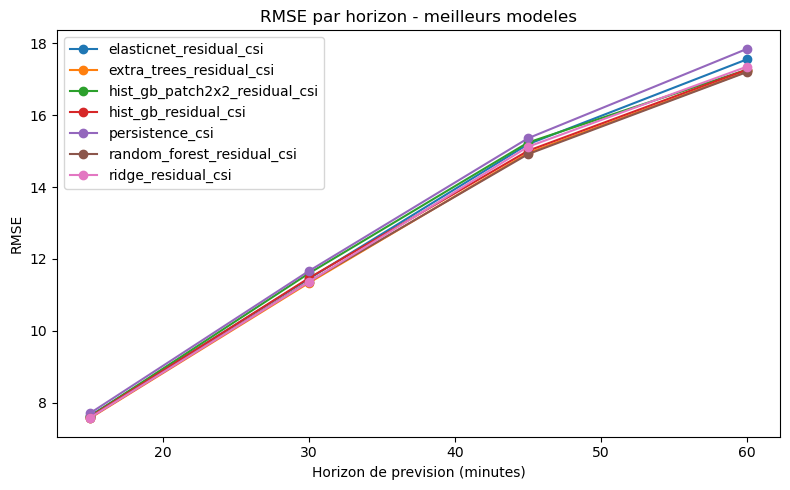

Meilleur modele global: random_forest_residual_csi


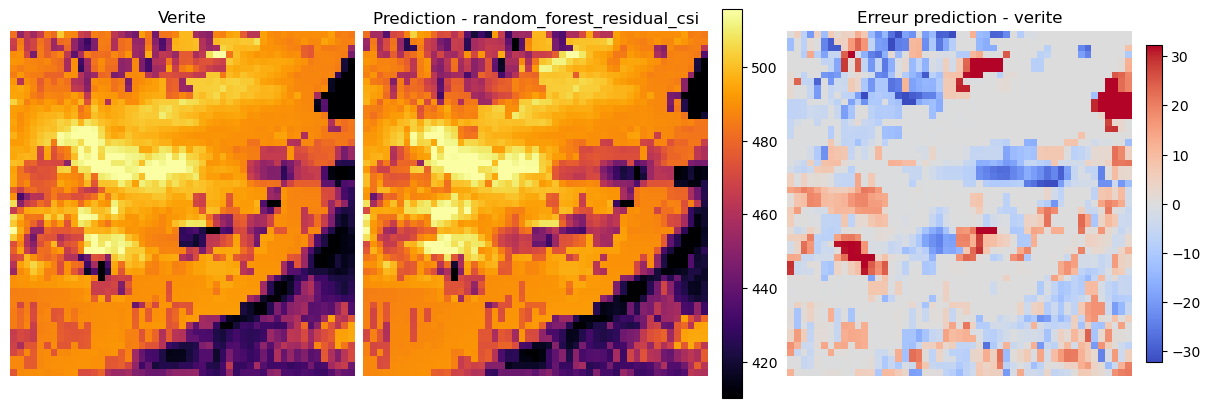

Modeles qui battent la persistance CSI:


,model,RMSE,MAE,skill_RMSE_vs_CSI
0,random_forest_residual_csi,13.278936,6.398546,0.059543
1,extra_trees_residual_csi,13.282668,6.381932,0.059014
2,hist_gb_residual_csi,13.350894,6.699421,0.049322
3,ridge_residual_csi,13.383484,6.542297,0.044675
4,hist_gb_patch2x2_residual_csi,13.445898,6.875939,0.035744
5,elasticnet_residual_csi,13.494951,6.855626,0.028696


In [ ]:
final_diagnostics = build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)
final_table = final_diagnostics["global"]
display(final_table)
display(final_diagnostics["by_horizon"].sort_values(["horizon_min", "RMSE"]))
display(final_diagnostics["spatial_structure"].sort_values(["horizon_min", "RMSE_structure"]))

top_models = list(final_table["model"].head(min(7, len(final_table))))
plot_metric_by_horizon(final_diagnostics["by_horizon"], models=top_models, metric="RMSE", title="RMSE par horizon - meilleurs modeles")
plt.show()

best_model_name = final_table.iloc[0]["model"]
print("Meilleur modele global:", best_model_name)
plot_forecast_triplet(val_target, predictions[best_model_name], sample_idx=0, horizon_idx=0, model_name=best_model_name)
plt.show()

winners = final_table.query("model != @MAIN_REFERENCE_NAME and skill_RMSE_vs_CSI > 0")
if len(winners):
    print("Modeles qui battent la persistance CSI:")
    display(winners[["model", "RMSE", "MAE", "skill_RMSE_vs_CSI"]])
else:
    print("Aucun modele ne bat la persistance CSI sur ce run.")

## Bloc E - Interpretation / XAI

On interprete le meilleur modele arbre disponible. La lecture physique attendue:

- CSI et CLS expliquent le niveau d'irradiance attendu.
- Angles solaires capturent la geometrie du soleil.
- Motion features indiquent si le deplacement nuageux est utile.
- Texture et spatial dynamics caracterisent la complexite des nuages.

Modele interprete: random_forest_residual_csi


,feature,importance
0,adv_quad1_csi_diff_last_minus_prev,0.150893
1,phys_CSI_q75_t2,0.075131
2,phys_CSI_q75_t0,0.050947
3,adv_quad1_ghi_diff_last_minus_prev,0.050778
4,phys_CSI_q25_t1,0.050347
5,spdyn_quad1_csi_diff_last_minus_prev,0.050094
6,spdyn_quad3_csi_diff_last_minus_prev,0.034794
7,adv_quad0_ghi_diff_last_minus_prev,0.032351
8,phys_CSI_q50_t2,0.030761
9,adv_ghi_diff_mean_t2,0.029916


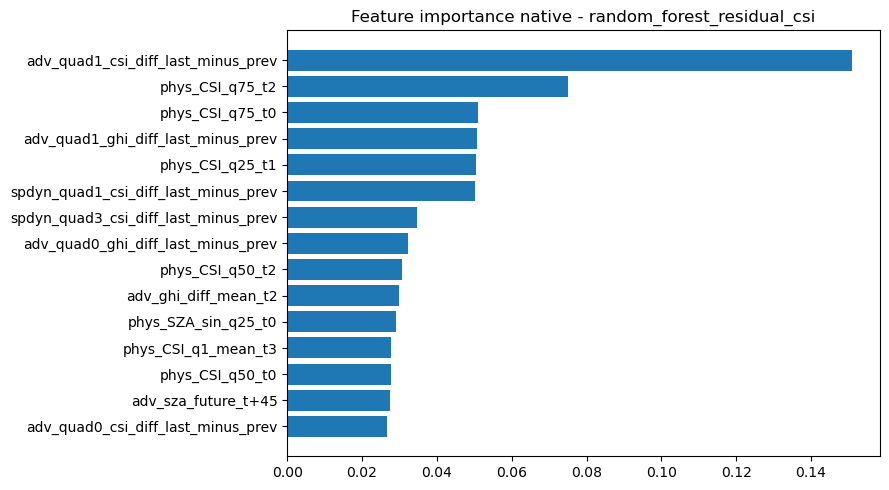

,feature,importance_mean,importance_std,baseline_score
0,adv_quad1_csi_diff_last_minus_prev,2.263376e-01,1.082804e-01,1.044292
1,adv_quad3_csi_diff_last_minus_prev,1.979443e-01,8.583892e-02,1.044292
2,spdyn_quad1_csi_diff_last_minus_prev,1.355454e-01,6.786346e-03,1.044292
3,spdyn_quad3_csi_diff_last_minus_prev,7.888443e-02,1.136989e-01,1.044292
4,tex_csi_t-1_gabor_p90,3.693526e-02,1.646548e-02,1.044292
5,phys_GHI_min_t3,6.762162e-03,5.326493e-03,1.044292
6,phys_CSI_min_t3,4.396569e-04,1.943958e-03,1.044292
7,phys_SAA_sin_q75_t6,2.220446e-16,0.000000e+00,1.044292
8,phys_SZA_cos_q3_mean_t7,2.220446e-16,0.000000e+00,1.044292
9,phys_SAA_sin_q50_t7,2.220446e-16,0.000000e+00,1.044292


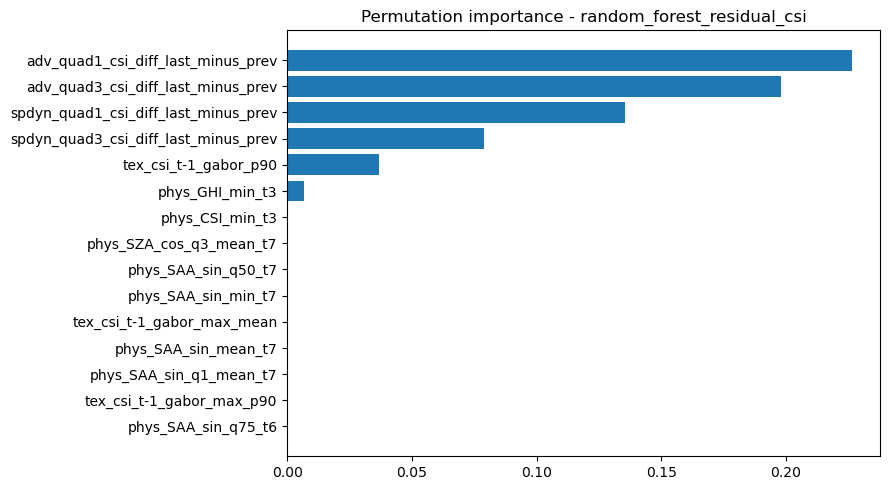

RUN_SHAP=False: SHAP garde en option pour l'environnement avec shap installe.


In [ ]:
if RUN_XAI:
    candidate_names = [
        "hist_gb_patch2x2_residual_csi",
        "hist_gb_residual_csi",
        "extra_trees_residual_csi",
        "random_forest_residual_csi",
        "ridge_residual_csi",
    ]
    available = [name for name in candidate_names if name in model_registry]
    if not available:
        print("Aucun modele interpretable disponible dans model_registry.")
    else:
        xai_name = (
            final_table[final_table["model"].isin(available)]
            .sort_values("RMSE")
            .iloc[0]["model"]
        )
        xai_model = model_registry[xai_name]
        if "patch2x2" in xai_name:
            y_xai = residual_patch_val
        else:
            y_xai = residual_val

        print("Modele interprete:", xai_name)
        native_imp = model_feature_importances(xai_model, feature_names)
        if len(native_imp):
            display(native_imp.head(25))
            fig, ax = plt.subplots(figsize=(9, 5))
            top = native_imp.head(15).sort_values("importance")
            ax.barh(top["feature"], top["importance"])
            ax.set_title(f"Feature importance native - {xai_name}")
            plt.tight_layout()
            plt.show()

        perm = permutation_importance_multioutput(
            xai_model,
            X_val_tab,
            y_xai,
            feature_names,
            n_repeats=3,
            random_state=RANDOM_STATE,
            max_features=60 if RUN_FAST else None,
        )
        display(perm.importance.head(25))
        fig, ax = plt.subplots(figsize=(9, 5))
        top = perm.importance.head(15).sort_values("importance_mean")
        ax.barh(top["feature"], top["importance_mean"])
        ax.set_title(f"Permutation importance - {xai_name}")
        plt.tight_layout()
        plt.show()

        if RUN_SHAP:
            try:
                shap_values, X_shap, shap_feature_names = compute_tree_shap_values(
                    xai_model,
                    X_val_tab,
                    feature_names,
                    output_index=0,
                    max_samples=100,
                )
                import shap
                shap.plots.bar(shap_values, max_display=15, show=False)
                plt.tight_layout()
                plt.show()
            except Exception as exc:
                print("SHAP non execute:", exc)
        else:
            print("RUN_SHAP=False: SHAP garde en option pour l'environnement avec shap installe.")

## Conclusion beta

Cette version beta est structuree comme le rendu final. Elle peut etre executee localement pour les blocs A, B, C et E. Le bloc D est prevu pour Colab; ses predictions doivent ensuite etre sauvegardees dans `OUTPUT_DIR` et rechargees dans la comparaison finale.